# Лабораторная работа 5: Классификация (Вариант 3)

## Обнаружение мошеннических транзакций в электронной коммерции

### Цель работы
Изучение алгоритмов и методов классификации на практике. Разработка предсказательной модели для определения мошеннических транзакций в электронной коммерции используя методы:
- Метод k-ближайших соседей (KNeighborsClassifier)
- Дерево решений (DecisionTreeClassifier)
- Логистическая регрессия (LogisticRegression)
- Случайный лес (RandomForestClassifier)

### Описание набора данных
Набор данных содержит информацию о 3024 транзакциях электронной коммерции с 11 признаками и целевым классом (мошенническая или нормальная).

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Загрузка и первичный анализ данных

Происходит загрузка файла, описание его признаков, а также предварительная обработка:

In [27]:
df = pd.read_csv('C:\\Users\\vanya\\Downloads\\ecommerce_fraud.csv')

print('Форма датасета:', df.shape)
print('\nПервые 5 строк датасета:')
print(df.head())
print('\nТипы данных:')
print(df.dtypes)
print('\nОписательная статистика:')
print(df.describe())

Форма датасета: (3024, 12)

Первые 5 строк датасета:
   transaction_amount device_type browser payment_method country  num_items  \
0               62.18     Desktop  Safari            COD      UK          3   
1               28.16     Desktop  Chrome            COD      US          2   
2               17.57      Mobile  Chrome           Card      DE          1   
3               61.61     Desktop  Safari         PayPal   Other          4   
4                4.28     Desktop    Edge           Card      BR          7   

   time_on_site_sec is_first_purchase referral  hour_of_day  account_age_days  \
0              58.0                No   Direct           15               808   
1              75.0               Yes   Direct           10               753   
2             101.0                No   Social           21              1017   
3              63.0               Yes   Search           20              1146   
4             399.0                No   Direct            4        

In [28]:
print('Пропущенные значения:')
print(df.isnull().sum())
print('\nОбщее количество пропусков:', df.isnull().sum().sum())

print('\nРаспределение целевого класса (Fraud):')
print(df['Fraud'].value_counts())
print('\nПроцент мошеннических транзакций:', 
      f"{(df['Fraud'].sum() / len(df) * 100):.2f}%")

Пропущенные значения:
transaction_amount    0
device_type           0
browser               0
payment_method        0
country               0
num_items             0
time_on_site_sec      0
is_first_purchase     0
referral              0
hour_of_day           0
account_age_days      0
Fraud                 0
dtype: int64

Общее количество пропусков: 0

Распределение целевого класса (Fraud):
Fraud
0    2889
1     135
Name: count, dtype: int64

Процент мошеннических транзакций: 4.46%


In [29]:
print('Уникальные значения категориальных признаков:')
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}: {sorted(df[col].unique())}")

print('\nЧисленные признаки (числовые):')
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(list(numeric_cols))

Уникальные значения категориальных признаков:
device_type: ['Desktop', 'Mobile', 'Tablet']
browser: ['Chrome', 'Edge', 'Firefox', 'Other', 'Safari']
payment_method: ['BankTransfer', 'COD', 'Card', 'PayPal']
country: ['BR', 'CN', 'DE', 'FR', 'IN', 'Other', 'UK', 'US']
is_first_purchase: ['No', 'Yes']
referral: ['Ads', 'Direct', 'Search', 'Social']

Численные признаки (числовые):
['transaction_amount', 'num_items', 'time_on_site_sec', 'hour_of_day', 'account_age_days', 'Fraud']


Как видно из предварительной обработки данных, ключевой колонкой является колонка “Fraud”, нет пропущенных значений, а также неявных дубликаций, что упрощает обработку данных и говорит о том, что данные готовы к работе.

## 2. Построение матрицы диаграмм рассеяния

Выделим значения целевой переменной разными цветами для визуализации их распределения.

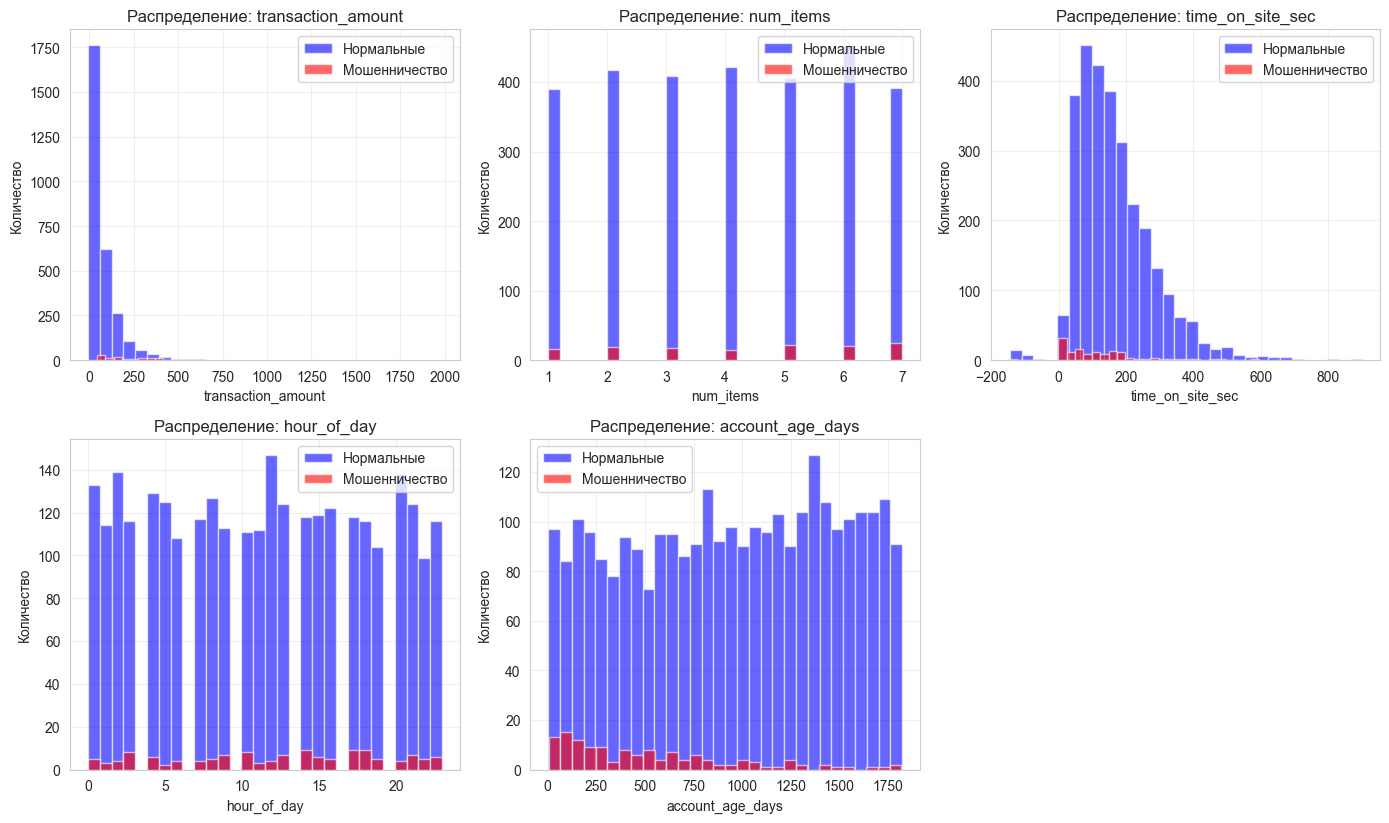

Матрица диаграмм распределения численных признаков по классам построена.


In [31]:
target = df['Fraud']
numeric_features = df.select_dtypes(include=[np.number]).drop('Fraud', axis=1)

data_for_scatter = numeric_features.copy()
data_for_scatter['Fraud'] = target

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

numeric_cols = list(numeric_features.columns)
for idx, col in enumerate(numeric_cols):
    normal = data_for_scatter[data_for_scatter['Fraud'] == 0][col]
    fraud = data_for_scatter[data_for_scatter['Fraud'] == 1][col]
    
    axes[idx].hist(normal, bins=30, alpha=0.6, label='Нормальные', color='blue')
    axes[idx].hist(fraud, bins=30, alpha=0.6, label='Мошенничество', color='red')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Количество')
    axes[idx].set_title(f'Распределение: {col}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()
print('Матрица диаграмм распределения численных признаков по классам построена.')

Как видно из графиков, мошеннические транзакции составляют довольно малую часть общего количества транзакций, что усложняет поиск закономерностей. Также видно невооруженным взглядом, что мошеннические транзакции по графику time_on_site_sec в основном занимают меньше времени, чем обычные.

## 3. Предварительная обработка данных (нормализация и стандартизация)

Перед предсказанием необходимо провести обработку данных, которая включает в себя: введение численных признаков вместо строковых, определение размера выборки для обучения, а также нормализацию и стандартизацию.

In [32]:
df_processed = df.copy()
categorical_features = df_processed.select_dtypes(include='object').columns.tolist()
print(f'Категориальные признаки: {categorical_features}')
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_processed[categorical_features] = encoder.fit_transform(df_processed[categorical_features])

print('\nДанные после кодирования категориальных признаков:')
print(df_processed.dtypes)
print('\nПервые 5 строк после обработки:')
print(df_processed.head())

Категориальные признаки: ['device_type', 'browser', 'payment_method', 'country', 'is_first_purchase', 'referral']

Данные после кодирования категориальных признаков:
transaction_amount    float64
device_type           float64
browser               float64
payment_method        float64
country               float64
num_items               int64
time_on_site_sec      float64
is_first_purchase     float64
referral              float64
hour_of_day             int64
account_age_days        int64
Fraud                   int64
dtype: object

Первые 5 строк после обработки:
   transaction_amount  device_type  browser  payment_method  country  \
0               62.18          0.0      4.0             1.0      6.0   
1               28.16          0.0      0.0             1.0      7.0   
2               17.57          1.0      0.0             2.0      2.0   
3               61.61          0.0      4.0             3.0      5.0   
4                4.28          0.0      1.0             2.0      0.

In [33]:
X = df_processed.drop('Fraud', axis=1)
y = df_processed['Fraud']

print(f'Размер матрицы признаков X: {X.shape}')
print(f'Размер вектора целевой переменной y: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0, 
    stratify=y  
)

print('\nОбучающая выборка:')
print(f'  X_train размер: {X_train.shape}')
print(f'  y_train размер: {y_train.shape}')
print('\nТестовая выборка:')
print(f'  X_test размер: {X_test.shape}')
print(f'  y_test размер: {y_test.shape}')
print('\nРаспределение классов в обучающей выборке:')
print(y_train.value_counts())
print('\nРаспределение классов в тестовой выборке:')
print(y_test.value_counts())

Размер матрицы признаков X: (3024, 11)
Размер вектора целевой переменной y: (3024,)

Обучающая выборка:
  X_train размер: (2116, 11)
  y_train размер: (2116,)

Тестовая выборка:
  X_test размер: (908, 11)
  y_test размер: (908,)

Распределение классов в обучающей выборке:
Fraud
0    2022
1      94
Name: count, dtype: int64

Распределение классов в тестовой выборке:
Fraud
0    867
1     41
Name: count, dtype: int64


In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('Данные после стандартизации:')
print('\nСредние значения признаков (должны быть близки к 0):')
print(X_train_scaled.mean())
print('\nСтандартные отклонения признаков (должны быть близки к 1):')
print(X_train_scaled.std())

Данные после стандартизации:

Средние значения признаков (должны быть близки к 0):
transaction_amount    4.260402e-17
device_type           7.387495e-17
browser               6.044314e-17
payment_method        1.410340e-16
country               6.967751e-17
num_items             8.394881e-17
time_on_site_sec     -8.059086e-17
is_first_purchase    -3.357952e-17
referral              2.854260e-17
hour_of_day           8.394881e-18
account_age_days      9.150420e-17
dtype: float64

Стандартные отклонения признаков (должны быть близки к 1):
transaction_amount    1.000236
device_type           1.000236
browser               1.000236
payment_method        1.000236
country               1.000236
num_items             1.000236
time_on_site_sec      1.000236
is_first_purchase     1.000236
referral              1.000236
hour_of_day           1.000236
account_age_days      1.000236
dtype: float64


По итогам этой части работы категориальные признаки были представлены в виде числовых бинарных столбцов, выбрана обучающая выборка в размере 70%, а также данные представлены нормальным распределением со средним значением равным нулю. 

## 4. Обучение и оценка моделей классификации

Используется 4 алгоритма классификации (дерево решений, случайный лес, логическая регрессия и k- ближайших соседей). Для каждого из алгоритмов рассчитываются метрики качества (precision, recall, f1-score, support, accurancy, marco_avg и weight_avg). Для этого создается вспомогательная функция рассчета метрик для каждого из случаев

In [35]:
models_results = {}
def calculate_metrics(y_true, y_pred, y_pred_proba=None):
    """
    Функция для вычисления всех необходимых метрик качества классификации.
    
    Параметры:
    - y_true: истинные значения целевой переменной
    - y_pred: предсказанные классы моделью
    - y_pred_proba: вероятности принадлежности к классу 1 (используется для ROC AUC)
    
    Возвращает словарь с метриками.
    """
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred)
    }
    if y_pred_proba is not None:
        metrics['ROC AUC'] = roc_auc_score(y_true, y_pred_proba)
    
    return metrics

print('Функция для расчёта метрик определена.')

Функция для расчёта метрик определена.


In [36]:
print('1. МЕТОД K-БЛИЖАЙШИХ СОСЕДЕЙ (KNeighborsClassifier)')

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_proba = knn.predict_proba(X_test_scaled)[:, 1]

knn_metrics = calculate_metrics(y_test, knn_pred, knn_proba)
models_results['KNN'] = knn_metrics

print('\nМетрики качества для KNN:')
for metric_name, metric_value in knn_metrics.items():
    print(f'  {metric_name}: {metric_value:.4f}')

knn_cm = confusion_matrix(y_test, knn_pred)
print('\nМатрица ошибок (Confusion Matrix):')
print(knn_cm)
print('\nОтчёт классификации:')
print(classification_report(y_test, knn_pred, zero_division=0))

1. МЕТОД K-БЛИЖАЙШИХ СОСЕДЕЙ (KNeighborsClassifier)

Метрики качества для KNN:
  Accuracy: 0.9493
  Precision: 0.3077
  Recall: 0.0976
  F1 Score: 0.1481
  Balanced Accuracy: 0.5436
  ROC AUC: 0.6566

Матрица ошибок (Confusion Matrix):
[[858   9]
 [ 37   4]]

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       867
           1       0.31      0.10      0.15        41

    accuracy                           0.95       908
   macro avg       0.63      0.54      0.56       908
weighted avg       0.93      0.95      0.94       908



In [37]:
print('2. ДЕРЕВО РЕШЕНИЙ (DecisionTreeClassifier)')
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
dt_proba = dt.predict_proba(X_test_scaled)[:, 1]
dt_metrics = calculate_metrics(y_test, dt_pred, dt_proba)
models_results['DecisionTree'] = dt_metrics

print('\nМетрики качества для дерева решений:')
for metric_name, metric_value in dt_metrics.items():
    print(f'  {metric_name}: {metric_value:.4f}')

dt_cm = confusion_matrix(y_test, dt_pred)
print('\nМатрица ошибок (Confusion Matrix):')
print(dt_cm)
print('\nОтчёт классификации:')
print(classification_report(y_test, dt_pred, zero_division=0))

2. ДЕРЕВО РЕШЕНИЙ (DecisionTreeClassifier)

Метрики качества для дерева решений:
  Accuracy: 0.9405
  Precision: 0.3488
  Recall: 0.3659
  F1 Score: 0.3571
  Balanced Accuracy: 0.6668
  ROC AUC: 0.6851

Матрица ошибок (Confusion Matrix):
[[839  28]
 [ 26  15]]

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       867
           1       0.35      0.37      0.36        41

    accuracy                           0.94       908
   macro avg       0.66      0.67      0.66       908
weighted avg       0.94      0.94      0.94       908



In [38]:
print('3. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (LogisticRegression)')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_metrics = calculate_metrics(y_test, lr_pred, lr_proba)
models_results['LogisticRegression'] = lr_metrics
print('\nМетрики качества для логистической регрессии:')
for metric_name, metric_value in lr_metrics.items():
    print(f'  {metric_name}: {metric_value:.4f}')

lr_cm = confusion_matrix(y_test, lr_pred)
print('\nМатрица ошибок (Confusion Matrix):')
print(lr_cm)
print('\nОтчёт классификации:')
print(classification_report(y_test, lr_pred, zero_division=0))

3. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (LogisticRegression)

Метрики качества для логистической регрессии:
  Accuracy: 0.9548
  Precision: 0.5000
  Recall: 0.0976
  F1 Score: 0.1633
  Balanced Accuracy: 0.5465
  ROC AUC: 0.8964

Матрица ошибок (Confusion Matrix):
[[863   4]
 [ 37   4]]

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       867
           1       0.50      0.10      0.16        41

    accuracy                           0.95       908
   macro avg       0.73      0.55      0.57       908
weighted avg       0.94      0.95      0.94       908



In [39]:
print('4. СЛУЧАЙНЫЙ ЛЕС (RandomForestClassifier)')
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]
rf_metrics = calculate_metrics(y_test, rf_pred, rf_proba)
models_results['RandomForest'] = rf_metrics

print('\nМетрики качества для случайного леса:')
for metric_name, metric_value in rf_metrics.items():
    print(f'  {metric_name}: {metric_value:.4f}')

rf_cm = confusion_matrix(y_test, rf_pred)
print('\nМатрица ошибок (Confusion Matrix):')
print(rf_cm)
print('\nОтчёт классификации:')
print(classification_report(y_test, rf_pred, zero_division=0))

4. СЛУЧАЙНЫЙ ЛЕС (RandomForestClassifier)

Метрики качества для случайного леса:
  Accuracy: 0.9570
  Precision: 0.5833
  Recall: 0.1707
  F1 Score: 0.2642
  Balanced Accuracy: 0.5825
  ROC AUC: 0.8470

Матрица ошибок (Confusion Matrix):
[[862   5]
 [ 34   7]]

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       867
           1       0.58      0.17      0.26        41

    accuracy                           0.96       908
   macro avg       0.77      0.58      0.62       908
weighted avg       0.94      0.96      0.95       908



При классификации использовались следующие метрики качества: precision (доля верно предсказанных примеров без учета ложно-положительных), recall (доля предсказанных примеров модель правильно определила), f1-score (гармоническое среднее между precision и recall), support (количественная колонка) для каждого из класса (0 и 1). Также оценивается точность предсказания accuracy (доля общего числа правильно предсказанных объектов от общего числа предсказаний), macro_avg (учитывает разную мощность классов), а также weighted avg (исходит из прямого количества объектов в каждом из классе для других метрик).

## 5. Матрицы ошибок для всех методов

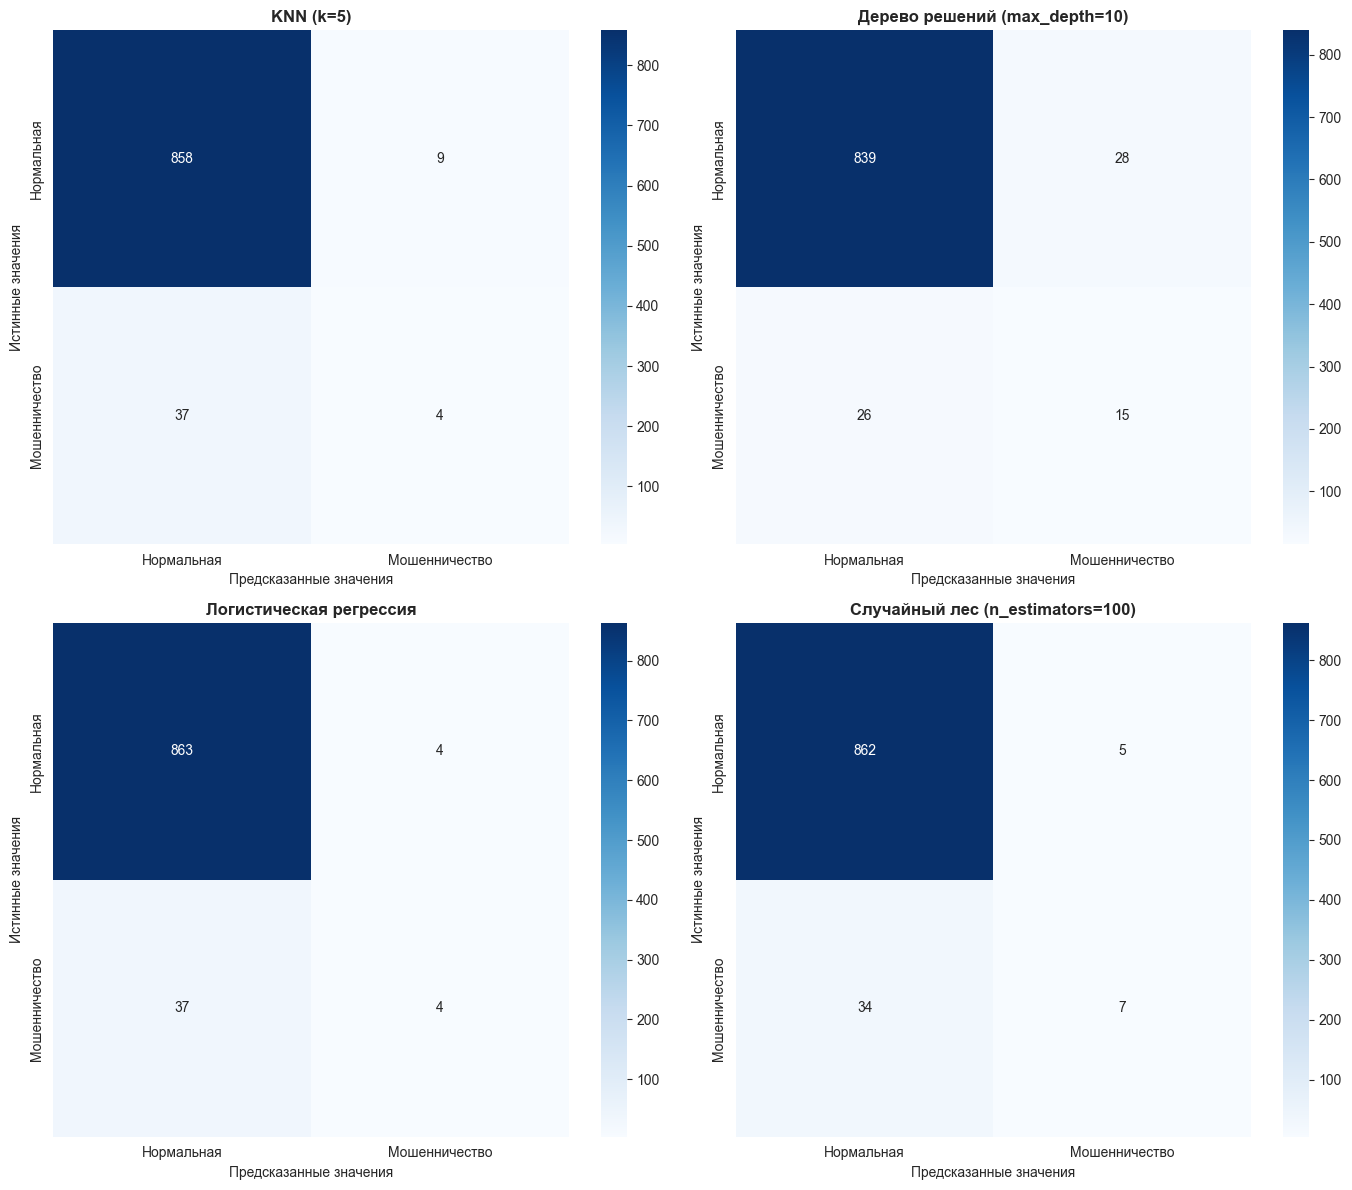

Матрицы ошибок для всех четырёх методов визуализированы.


In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
confusion_matrices = [
    (knn_cm, 'KNN (k=5)', axes[0]),
    (dt_cm, 'Дерево решений (max_depth=10)', axes[1]),
    (lr_cm, 'Логистическая регрессия', axes[2]),
    (rf_cm, 'Случайный лес (n_estimators=100)', axes[3])
]

for cm, title, ax in confusion_matrices:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Предсказанные значения')
    ax.set_ylabel('Истинные значения')
    ax.set_xticklabels(['Нормальная', 'Мошенничество'])
    ax.set_yticklabels(['Нормальная', 'Мошенничество'])

plt.tight_layout()
plt.show()
print('Матрицы ошибок для всех четырёх методов визуализированы.')

Исходя из матрицы ошибок видно, что количество истинно-положительных транзакций преобладает, однако учитывая разную мощность классов, количество ошибок все еще остается довольно высоким.

## 6. ROC-кривые и AUC для сравнения моделей

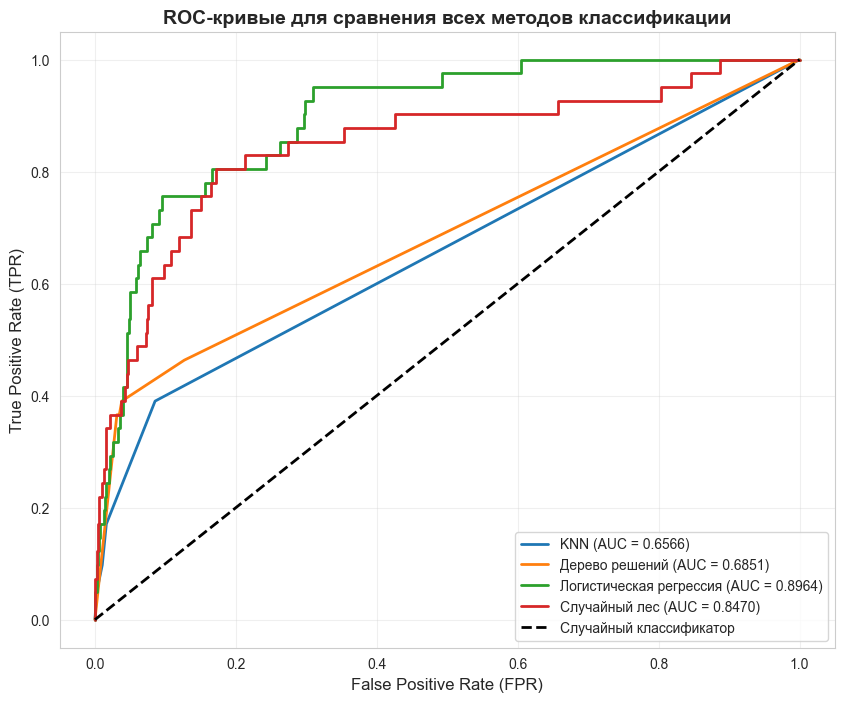

ROC-кривые для всех четырёх методов построены на одном графике.


In [41]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_proba)
roc_auc_knn = auc(fpr_knn, tpr_knn)

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(10, 8))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.4f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Дерево решений (AUC = {roc_auc_dt:.4f})', linewidth=2)
plt.plot(fpr_lr, tpr_lr, label=f'Логистическая регрессия (AUC = {roc_auc_lr:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Случайный лес (AUC = {roc_auc_rf:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор', linewidth=2)

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривые для сравнения всех методов классификации', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print('ROC-кривые для всех четырёх методов построены на одном графике.')

Как видно из графика, лучшей моделей обучения является логистическая регрессия, после чего идет модель Случайного леса. Две другие модели довольно сильно отличаются по значению, что делает их не конкурентноспособными для данной задачи.

## 7. Сравнительный анализ всех методов

Сравнительная таблица всех метрик для всех методов классификации:
                         Accuracy  Precision  Recall  F1 Score  \
KNN (k=5)                  0.9493     0.3077  0.0976    0.1481   
Дерево решений             0.9405     0.3488  0.3659    0.3571   
Логистическая регрессия    0.9548     0.5000  0.0976    0.1633   
Случайный лес              0.9570     0.5833  0.1707    0.2642   

                         Balanced Accuracy  ROC AUC  
KNN (k=5)                           0.5436   0.6566  
Дерево решений                      0.6668   0.6851  
Логистическая регрессия             0.5465   0.8964  
Случайный лес                       0.5825   0.8470  


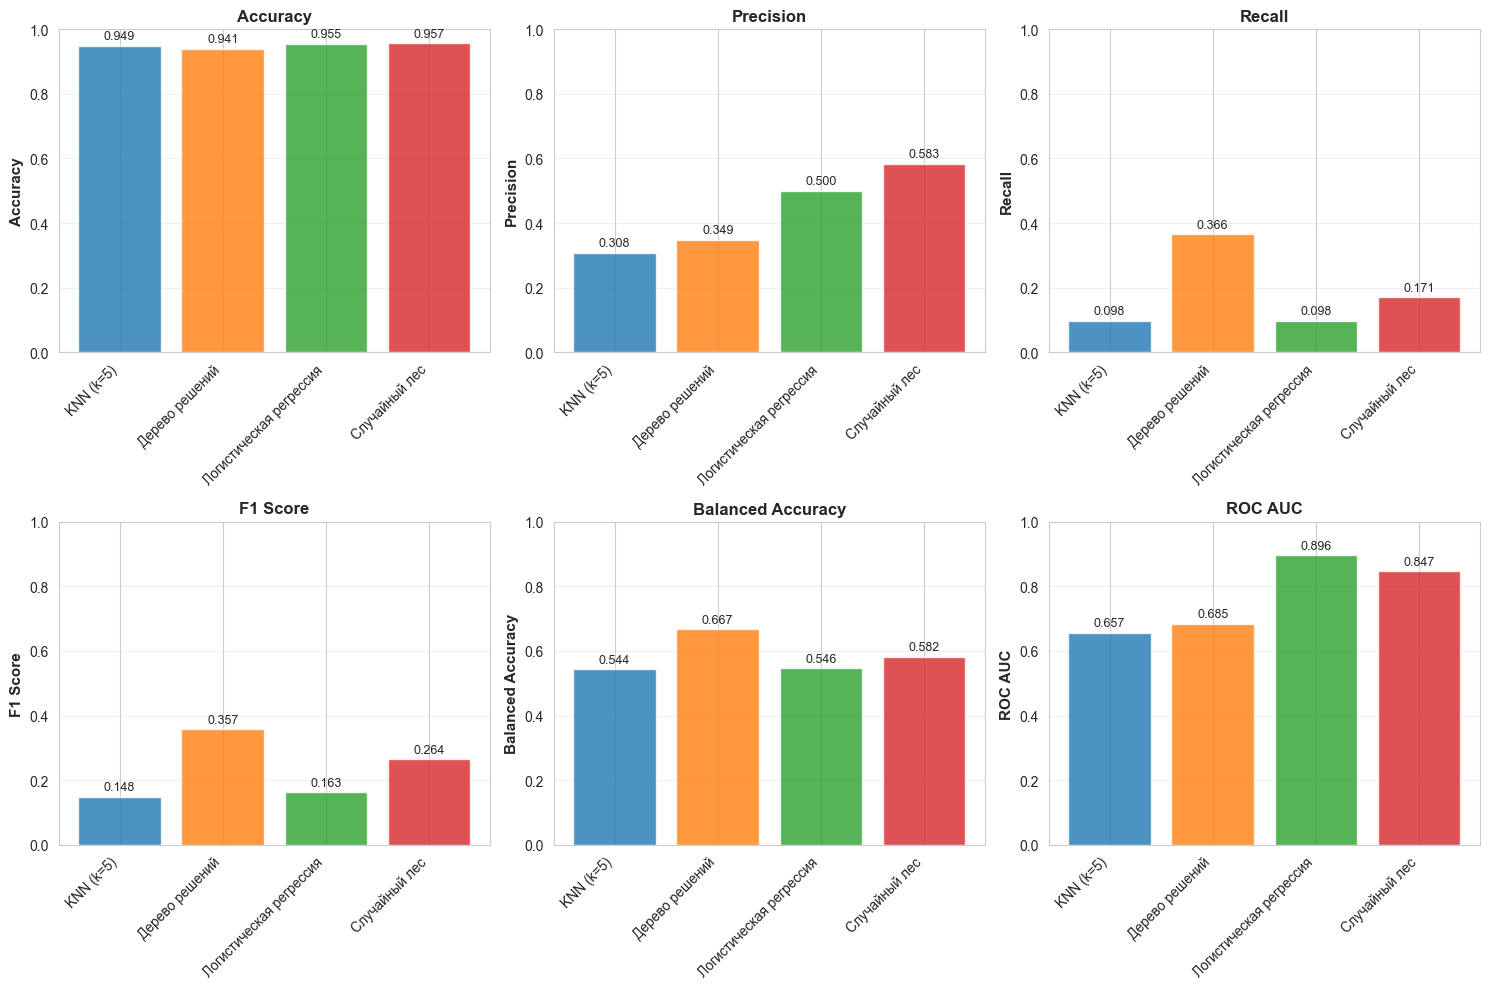


Графики сравнения метрик построены.


In [85]:
models_results['KNN']['ROC AUC'] = roc_auc_knn
models_results['DecisionTree']['ROC AUC'] = roc_auc_dt
models_results['LogisticRegression']['ROC AUC'] = roc_auc_lr
models_results['RandomForest']['ROC AUC'] = roc_auc_rf

comparison_df = pd.DataFrame(models_results).T
comparison_df.index = ['KNN (k=5)', 'Дерево решений', 'Логистическая регрессия', 'Случайный лес']

print('Сравнительная таблица всех метрик для всех методов классификации:')
print(comparison_df.round(4))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Balanced Accuracy', 'ROC AUC']

for idx, metric in enumerate(metrics_to_plot):
    values = comparison_df[metric].values
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    axes[idx].bar(range(len(comparison_df)), values, color=colors, alpha=0.8)
    axes[idx].set_xticks(range(len(comparison_df)))
    axes[idx].set_xticklabels(comparison_df.index, rotation=45, ha='right')
    axes[idx].set_ylabel(metric, fontsize=11, fontweight='bold')
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    
    for i, v in enumerate(values):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print('\nГрафики сравнения метрик построены.')

Исходя из данной гистограммы видно, как сказывается проблема нехватки данных о мошеннических транзакциях (из-за этого такие критерии, как «полнота», f1, а также сбалансированная точность остаются довольно низкими).

## 8. Анализ важности признаков

Важность признаков для дерева решений:
               Feature  Importance
0   transaction_amount    0.406475
6     time_on_site_sec    0.263761
10    account_age_days    0.137509
3       payment_method    0.051293
9          hour_of_day    0.045741
4              country    0.031337
2              browser    0.025442
8             referral    0.016230
5            num_items    0.013249
1          device_type    0.008964
7    is_first_purchase    0.000000


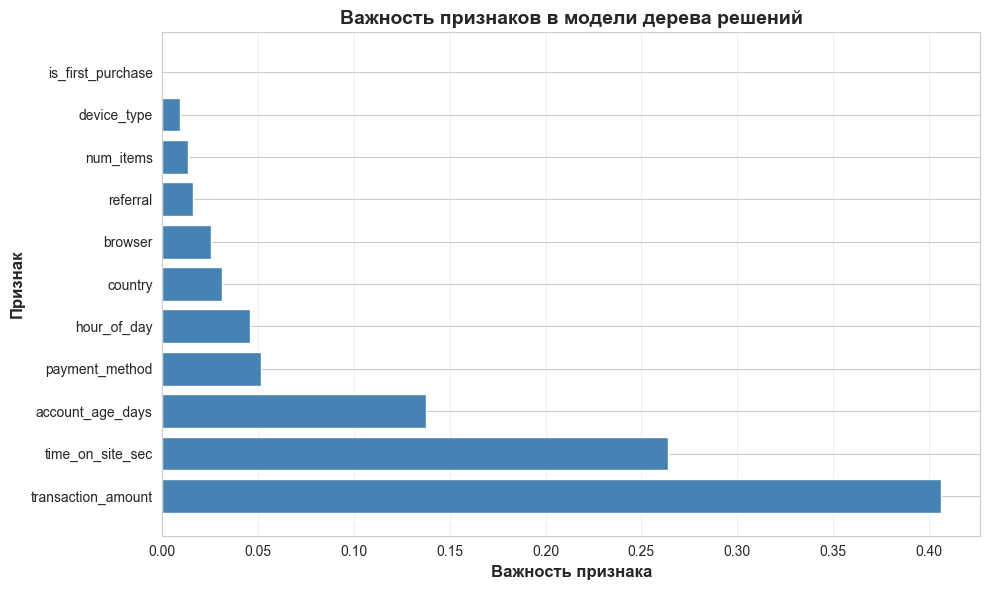

In [43]:
dt_feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print('Важность признаков для дерева решений:')
print(dt_feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(dt_feature_importance['Feature'], dt_feature_importance['Importance'], color='steelblue')
plt.xlabel('Важность признака', fontsize=12, fontweight='bold')
plt.ylabel('Признак', fontsize=12, fontweight='bold')
plt.title('Важность признаков в модели дерева решений', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Важность признаков для случайного леса:
               Feature  Importance
0   transaction_amount    0.341436
6     time_on_site_sec    0.205337
10    account_age_days    0.177445
9          hour_of_day    0.068467
4              country    0.039295
5            num_items    0.038971
2              browser    0.029678
8             referral    0.029073
1          device_type    0.027590
3       payment_method    0.025450
7    is_first_purchase    0.017260


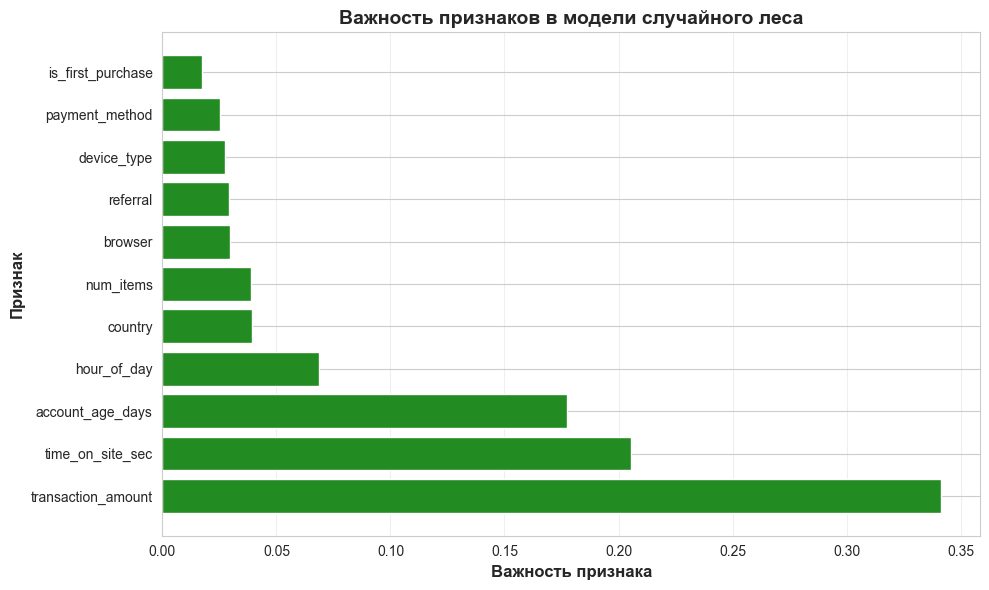

In [44]:
rf_feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print('Важность признаков для случайного леса:')
print(rf_feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'], color='forestgreen')
plt.xlabel('Важность признака', fontsize=12, fontweight='bold')
plt.ylabel('Признак', fontsize=12, fontweight='bold')
plt.title('Важность признаков в модели случайного леса', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Стоит отметить, что первые 5 наиболее важных признаков у случайного леса и у дерева решений совпадают. Разница заключается лишь в колонках time_on_site_sec и account_age_days, которые находятся на 2 и 3 местах и наоборот. Это говорит о том, что подобные признаки действительно являются наиболее важными при предсказании результатов.

## ЗАДАНИЕ 10 - ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ С ПОМОЩЬЮ GridSearchCV

Осуществляем подбор оптимальных параметров для случайного леса с использованием GridSearchCV и сравниваем качество модели.

ЗАДАНИЕ 10 - ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ С ПОМОЩЬЮ GridSearchCV
  n_estimators: [50, 100, 200]
  max_depth: [5, 10, 15, 20]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

Общее количество комбинаций: 216 параметров

Запуск GridSearchCV (это может занять некоторое время)...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
РЕЗУЛЬТАТЫ GridSearchCV

Лучшие параметры: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Лучший F1-score (на кросс-валидации): 0.4478
СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ: ИСХОДНАЯ vs ОПТИМИЗИРОВАННАЯ

                    Исходный RF  Оптимизированный RF
Accuracy                0.9570               0.9570
Precision               0.5833               0.5833
Recall                  0.1707               0.1707
F1 Score                0.2642               0.2642
Balanced Accuracy       0.5825               0.5825
ROC AUC                 0.8470            

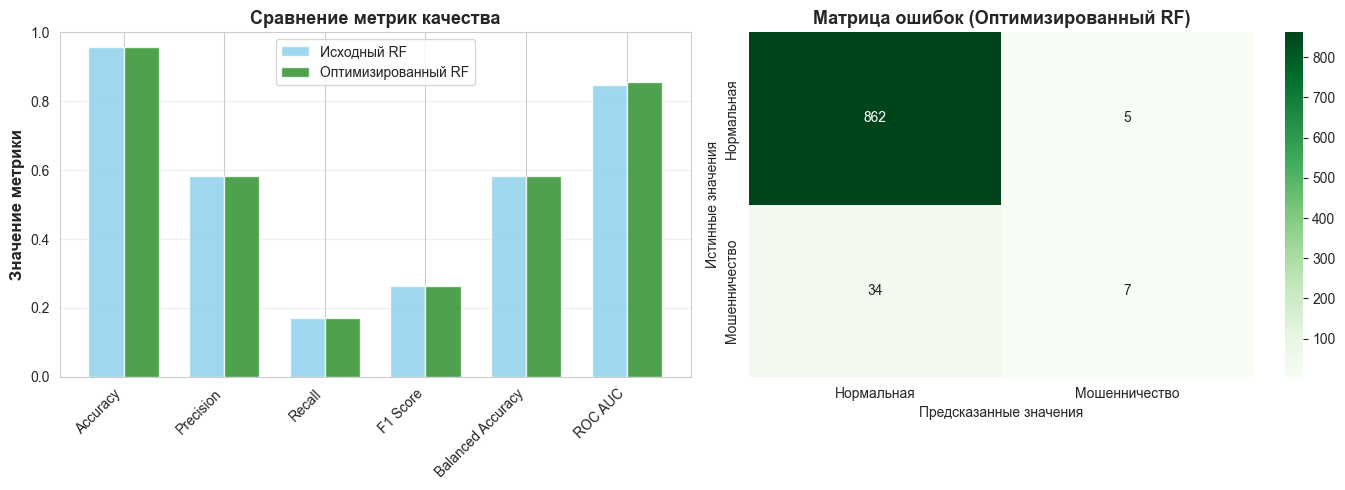

In [86]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

print('ЗАДАНИЕ 10 - ПОДБОР ОПТИМАЛЬНЫХ ПАРАМЕТРОВ С ПОМОЩЬЮ GridSearchCV')
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

for param, values in param_grid.items():
    print(f'  {param}: {values}')
print(f'\nОбщее количество комбинаций: {3*4*3*3*2} параметров')
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print('\nЗапуск GridSearchCV (это может занять некоторое время)...')
grid_search.fit(X_train_scaled.values, y_train.values)
print('РЕЗУЛЬТАТЫ GridSearchCV')
print(f'\nЛучшие параметры: {grid_search.best_params_}')
print(f'Лучший F1-score (на кросс-валидации): {grid_search.best_score_:.4f}')

rf_optimized = grid_search.best_estimator_
rf_optimized.fit(X_train_scaled, y_train)
rf_optimized_pred = rf_optimized.predict(X_test_scaled)
rf_optimized_proba = rf_optimized.predict_proba(X_test_scaled)[:, 1]
rf_optimized_metrics = calculate_metrics(y_test, rf_optimized_pred, rf_optimized_proba)

print('СРАВНЕНИЕ КАЧЕСТВА МОДЕЛЕЙ: ИСХОДНАЯ vs ОПТИМИЗИРОВАННАЯ')
comparison_rf = pd.DataFrame({
    'Исходный RF': models_results['RandomForest'],
    'Оптимизированный RF': rf_optimized_metrics
})
print('\n', comparison_rf.round(4))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Balanced Accuracy', 'ROC AUC']
x_pos = range(len(metrics))
original_values = [models_results['RandomForest'].get(m, 0) for m in metrics]
optimized_values = [rf_optimized_metrics.get(m, 0) for m in metrics]

width = 0.35
axes[0].bar([p - width/2 for p in x_pos], original_values, width, 
            label='Исходный RF', color='skyblue', alpha=0.8)
axes[0].bar([p + width/2 for p in x_pos], optimized_values, width, 
            label='Оптимизированный RF', color='forestgreen', alpha=0.8)
axes[0].set_ylabel('Значение метрики', fontsize=12, fontweight='bold')
axes[0].set_title('Сравнение метрик качества', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1])

rf_optimized_cm = confusion_matrix(y_test, rf_optimized_pred)
sns.heatmap(rf_optimized_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=True)
axes[1].set_title('Матрица ошибок (Оптимизированный RF)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Истинные значения')
axes[1].set_xticklabels(['Нормальная', 'Мошенничество'])
axes[1].set_yticklabels(['Нормальная', 'Мошенничество'])

plt.tight_layout()
plt.show()

Исходя из результата видно, что подбор наилучших параметров не дал практически никакого результата, что говорит о верности выбранных параметров.

## ЗАДАНИЕ 13 - РЕАЛИЗАЦИЯ ФУНКЦИИ СПЕЦИФИЧНОСТИ (TNR)

Реализуем функцию для вычисления специфичности (True Negative Rate) и применяем её для каждого метода.

В данном задании модель использует так называемый термин – специфичность, который сильно зависит от ложноположительной ошибки.

In [76]:
print('ЗАДАНИЕ 13 - ВЫЧИСЛЕНИЕ СПЕЦИФИЧНОСТИ (TNR)')
def calculate_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    if tn + fp == 0:
        return 0
    specificity = tn / (tn + fp)
    return specificity

print('\nФормула: TNR (специфичность) = TN / (TN + FP)')
print('где:')
print('  TN - истинные отрицательные (правильно определённые нормальные)')
print('  FP - ложные положительные (ошибочно определённые как мошеннические)')
print('СПЕЦИФИЧНОСТЬ (TNR) ДЛЯ КАЖДОГО МЕТОДА')
tnr_results = {}

knn_tnr = calculate_specificity(y_test, knn_pred)
tnr_results['KNN (k=5)'] = knn_tnr
print(f'\n1. KNN (k=5):')
print(f'   Специфичность (TNR): {knn_tnr:.4f} ({knn_tnr*100:.2f}%)')

dt_tnr = calculate_specificity(y_test, dt_pred)
tnr_results['Дерево решений'] = dt_tnr
print(f'\n2. Дерево решений (max_depth=10):')
print(f'   Специфичность (TNR): {dt_tnr:.4f} ({dt_tnr*100:.2f}%)')

lr_tnr = calculate_specificity(y_test, lr_pred)
tnr_results['Логистическая регрессия'] = lr_tnr
print(f'\n3. Логистическая регрессия:')
print(f'   Специфичность (TNR): {lr_tnr:.4f} ({lr_tnr*100:.2f}%)')

rf_tnr = calculate_specificity(y_test, rf_pred)
tnr_results['Случайный лес'] = rf_tnr
print(f'\n4. Случайный лес (n_estimators=100):')
print(f'   Специфичность (TNR): {rf_tnr:.4f} ({rf_tnr*100:.2f}%)')

rf_optimized_tnr = calculate_specificity(y_test, rf_optimized_pred)
tnr_results['Оптимизированный RF'] = rf_optimized_tnr
print(f'\n5. Оптимизированный случайный лес (GridSearchCV):')
print(f'   Специфичность (TNR): {rf_optimized_tnr:.4f} ({rf_optimized_tnr*100:.2f}%)')

ЗАДАНИЕ 13 - ВЫЧИСЛЕНИЕ СПЕЦИФИЧНОСТИ (TNR)

Формула: TNR (специфичность) = TN / (TN + FP)
где:
  TN - истинные отрицательные (правильно определённые нормальные)
  FP - ложные положительные (ошибочно определённые как мошеннические)
СПЕЦИФИЧНОСТЬ (TNR) ДЛЯ КАЖДОГО МЕТОДА

1. KNN (k=5):
   Специфичность (TNR): 0.9896 (98.96%)

2. Дерево решений (max_depth=10):
   Специфичность (TNR): 0.9677 (96.77%)

3. Логистическая регрессия:
   Специфичность (TNR): 0.9954 (99.54%)

4. Случайный лес (n_estimators=100):
   Специфичность (TNR): 0.9942 (99.42%)

5. Оптимизированный случайный лес (GridSearchCV):
   Специфичность (TNR): 0.9942 (99.42%)


Таким образом, специфичность лучше всего представлена в логистической регрессии, а хуже всего – в Дереве решений. Однако такой показатель остается довольно высоким для всех моделей.

## ДОПОЛНЕНИЕ: ЗАДАНИЕ 3 - ПРОВЕРКА И УСТРАНЕНИЕ ДИСБАЛАНСА КЛАССОВ

Проверяем дисбалансированность датасета и применяем SMOTE для его устранения.

Поскольку набор данных сильно дисбалансирован, требуется провести исследование приблизительно равных по количеству данных мошеннических и нормальных транзакций. Уменьшать выборку – не самая лучшая идея, поэтому можно заполнить класс мошеннических транзакций такими же мошенническими транзакциями. При этом если бы данные поступали извне – классификация модели таких транзакций бы не изменилась. Именно для этого применяется SMOTE.
Первым шагом является оценка дисбаланса и ответ на вопрос, а действительно ли нужно добавлять данные для корректной оценки

ЗАДАНИЕ 16 - ПРОВЕРКА ДИСБАЛАНСА КЛАССОВ
3.1 АНАЛИЗ ДИСБАЛАНСА КЛАССОВ В ИСХОДНОМ ДАТАСЕТЕ

Распределение классов в обучающей выборке:
  Класс 0 (нормальные): 2022 примеров (95.56%)
  Класс 1 (мошенничество): 94 примеров (4.44%)

Соотношение дисбаланса (Majority/Minority): 21.51:1

Оценка дисбаланса:
  Датасет СИЛЬНО ДИСБАЛАНСИРОВАН
  Требуется применение методов балансировки


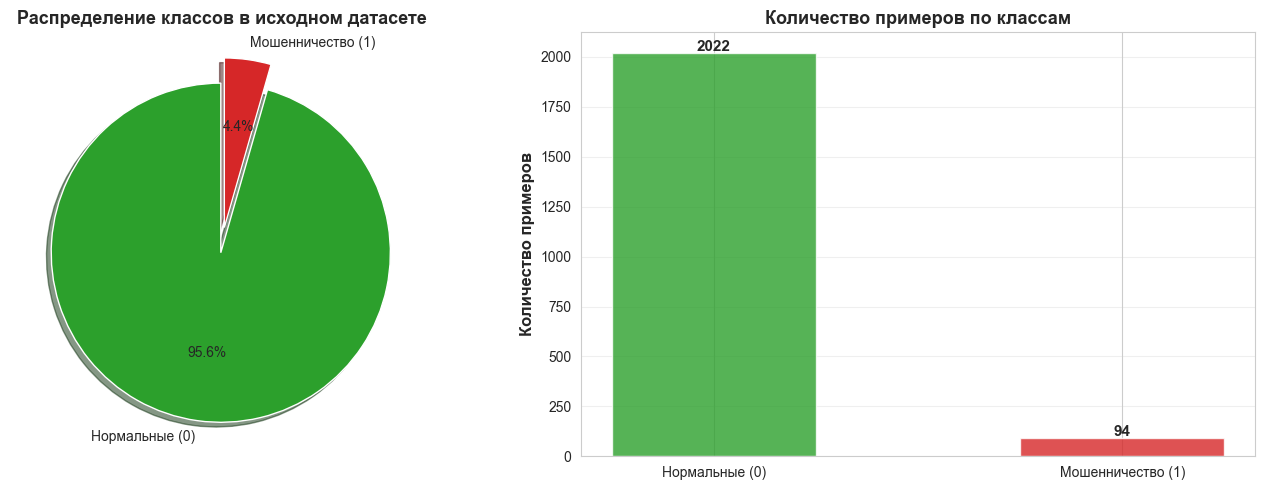

In [78]:
print('ЗАДАНИЕ 16 - ПРОВЕРКА ДИСБАЛАНСА КЛАССОВ')
print('3.1 АНАЛИЗ ДИСБАЛАНСА КЛАССОВ В ИСХОДНОМ ДАТАСЕТЕ')

class_distribution = y_train.value_counts()
class_percentages = y_train.value_counts(normalize=True) * 100
print('\nРаспределение классов в обучающей выборке:')
print(f'  Класс 0 (нормальные): {class_distribution[0]} примеров ({class_percentages[0]:.2f}%)')
print(f'  Класс 1 (мошенничество): {class_distribution[1]} примеров ({class_percentages[1]:.2f}%)')
imbalance_ratio = class_distribution[0] / class_distribution[1]
print(f'\nСоотношение дисбаланса (Majority/Minority): {imbalance_ratio:.2f}:1')
print('\nОценка дисбаланса:')
if imbalance_ratio > 10:
    print('  Датасет СИЛЬНО ДИСБАЛАНСИРОВАН')
    print('  Требуется применение методов балансировки')
elif imbalance_ratio > 3:
    print('  Датасет УМЕРЕННО ДИСБАЛАНСИРОВАН')
    print('  Рекомендуется применение методов балансировки')
else:
    print('  Датасет относительно сбалансирован')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['Нормальные (0)', 'Мошенничество (1)']
colors = ['#2ca02c', '#d62728']
explode = (0.05, 0.1)
axes[0].pie(class_distribution, labels=labels, autopct='%1.1f%%', 
            colors=colors, explode=explode, shadow=True, startangle=90)
axes[0].set_title('Распределение классов в исходном датасете', 
                  fontsize=13, fontweight='bold')
axes[1].bar(labels, class_distribution, color=colors, alpha=0.8, width=0.5)
axes[1].set_ylabel('Количество примеров', fontsize=12, fontweight='bold')
axes[1].set_title('Количество примеров по классам', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, (label, count) in enumerate(zip(labels, class_distribution)):
    axes[1].text(i, count + 10, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

По итогам такой оценки видно, что мошеннические транзакции отличаются на порядок от нормальных, что говорит о необходимости применения SMOTE 

3.2 ПРИМЕНЕНИЕ МЕТОДОВ БАЛАНСИРОВКИ КЛАССОВ

Используем SMOTE (Synthetic Minority Over-sampling Technique)
SMOTE создаёт синтетические примеры класса меньшинства на основе
существующих примеров, используя k-ближайших соседей.

Распределение классов после применения SMOTE:
  Класс 0 (нормальные): 2022 примеров (50.00%)
  Класс 1 (мошенничество): 2022 примеров (50.00%)
  Новое соотношение классов: 1:1


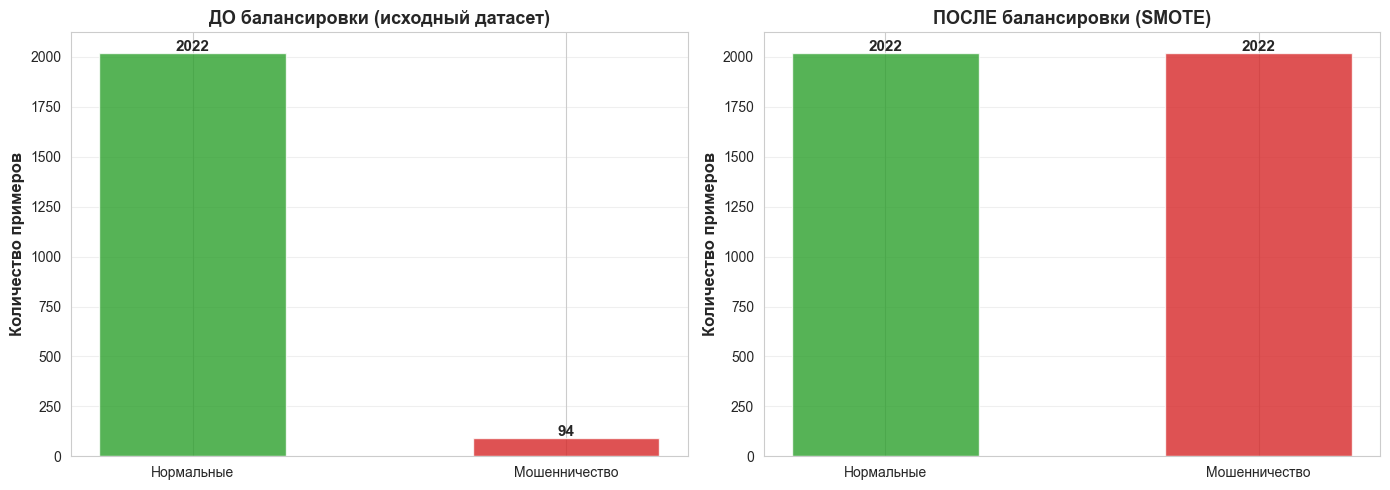

In [79]:
print('3.2 ПРИМЕНЕНИЕ МЕТОДОВ БАЛАНСИРОВКИ КЛАССОВ')
from imblearn.over_sampling import SMOTE
print('\nИспользуем SMOTE (Synthetic Minority Over-sampling Technique)')
print('SMOTE создаёт синтетические примеры класса меньшинства на основе')
print('существующих примеров, используя k-ближайших соседей.')

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print('\nРаспределение классов после применения SMOTE:')
balanced_class_distribution = pd.Series(y_train_balanced).value_counts()
balanced_percentages = pd.Series(y_train_balanced).value_counts(normalize=True) * 100
print(f'  Класс 0 (нормальные): {balanced_class_distribution[0]} примеров ({balanced_percentages[0]:.2f}%)')
print(f'  Класс 1 (мошенничество): {balanced_class_distribution[1]} примеров ({balanced_percentages[1]:.2f}%)')
print(f'  Новое соотношение классов: 1:1')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Нормальные', 'Мошенничество'], class_distribution, 
            color=['#2ca02c', '#d62728'], alpha=0.8, width=0.5)
axes[0].set_ylabel('Количество примеров', fontsize=12, fontweight='bold')
axes[0].set_title('ДО балансировки (исходный датасет)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

for i, (label, count) in enumerate(zip(['Нормальные', 'Мошенничество'], class_distribution)):
    axes[0].text(i, count + 10, str(count), ha='center', fontsize=11, fontweight='bold')

axes[1].bar(['Нормальные', 'Мошенничество'], balanced_class_distribution, 
            color=['#2ca02c', '#d62728'], alpha=0.8, width=0.5)
axes[1].set_ylabel('Количество примеров', fontsize=12, fontweight='bold')
axes[1].set_title('ПОСЛЕ балансировки (SMOTE)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for i, (label, count) in enumerate(zip(['Нормальные', 'Мошенничество'], balanced_class_distribution)):
    axes[1].text(i, count + 10, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Теперь с новыми данными повторяются все методы оценивания, которые уже приводились выше в данной работе

In [68]:
print('3.3 ПЕРЕОБУЧЕНИЕ МОДЕЛЕЙ НА СБАЛАНСИРОВАННЫХ ДАННЫХ')
models_balanced = {}

print('\n1. KNN на сбалансированных данных...')
knn_balanced = KNeighborsClassifier(n_neighbors=5)
knn_balanced.fit(X_train_balanced, y_train_balanced)
knn_balanced_pred = knn_balanced.predict(X_test_scaled)
knn_balanced_proba = knn_balanced.predict_proba(X_test_scaled)[:, 1]
knn_balanced_metrics = calculate_metrics(y_test, knn_balanced_pred, knn_balanced_proba)
models_balanced['KNN'] = knn_balanced_metrics

print('2. Дерево решений на сбалансированных данных...')
dt_balanced = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_balanced.fit(X_train_balanced, y_train_balanced)
dt_balanced_pred = dt_balanced.predict(X_test_scaled)
dt_balanced_proba = dt_balanced.predict_proba(X_test_scaled)[:, 1]
dt_balanced_metrics = calculate_metrics(y_test, dt_balanced_pred, dt_balanced_proba)
models_balanced['DecisionTree'] = dt_balanced_metrics

print('3. Логистическая регрессия на сбалансированных данных...')
lr_balanced = LogisticRegression(max_iter=1000, random_state=42)
lr_balanced.fit(X_train_balanced, y_train_balanced)
lr_balanced_pred = lr_balanced.predict(X_test_scaled)
lr_balanced_proba = lr_balanced.predict_proba(X_test_scaled)[:, 1]
lr_balanced_metrics = calculate_metrics(y_test, lr_balanced_pred, lr_balanced_proba)
models_balanced['LogisticRegression'] = lr_balanced_metrics

print('4. Случайный лес на сбалансированных данных...')
rf_balanced = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_balanced.fit(X_train_balanced, y_train_balanced)
rf_balanced_pred = rf_balanced.predict(X_test_scaled)
rf_balanced_proba = rf_balanced.predict_proba(X_test_scaled)[:, 1]
rf_balanced_metrics = calculate_metrics(y_test, rf_balanced_pred, rf_balanced_proba)
models_balanced['RandomForest'] = rf_balanced_metrics

print('5. Оптимизированный случайный лес на сбалансированных данных...')
rf_optimized_balanced = grid_search.best_estimator_.fit(X_train_balanced, y_train_balanced)
rf_opt_balanced_pred = rf_optimized_balanced.predict(X_test_scaled)
rf_opt_balanced_proba = rf_optimized_balanced.predict_proba(X_test_scaled)[:, 1]
rf_opt_balanced_metrics = calculate_metrics(y_test, rf_opt_balanced_pred, rf_opt_balanced_proba)
models_balanced['RandomForest_Optimized'] = rf_opt_balanced_metrics

print('\nВсе модели успешно переобучены на сбалансированных данных.')

3.3 ПЕРЕОБУЧЕНИЕ МОДЕЛЕЙ НА СБАЛАНСИРОВАННЫХ ДАННЫХ

1. KNN на сбалансированных данных...
2. Дерево решений на сбалансированных данных...
3. Логистическая регрессия на сбалансированных данных...
4. Случайный лес на сбалансированных данных...
5. Оптимизированный случайный лес на сбалансированных данных...

Все модели успешно переобучены на сбалансированных данных.


3.4 СРАВНЕНИЕ МОДЕЛЕЙ: ИСХОДНЫЕ vs СБАЛАНСИРОВАННЫЕ

                      Accuracy (до)  Accuracy (после)  Recall (до)  \
KNN                         0.9493            0.8855       0.0976   
Decision Tree               0.9405            0.8910       0.3659   
Logistic Regression         0.9548            0.8601       0.0976   
Random Forest               0.9570            0.9207       0.1707   
RF Optimized                0.9570            0.9438       0.1707   

                     Recall (после)  F1 Score (до)  F1 Score (после)  
KNN                          0.4146         0.1481            0.2464  
Decision Tree                0.5610         0.3571            0.3172  
Logistic Regression          0.7561         0.1633            0.3280  
Random Forest                0.4878         0.2642            0.3571  
RF Optimized                 0.3415         0.2642            0.3544  


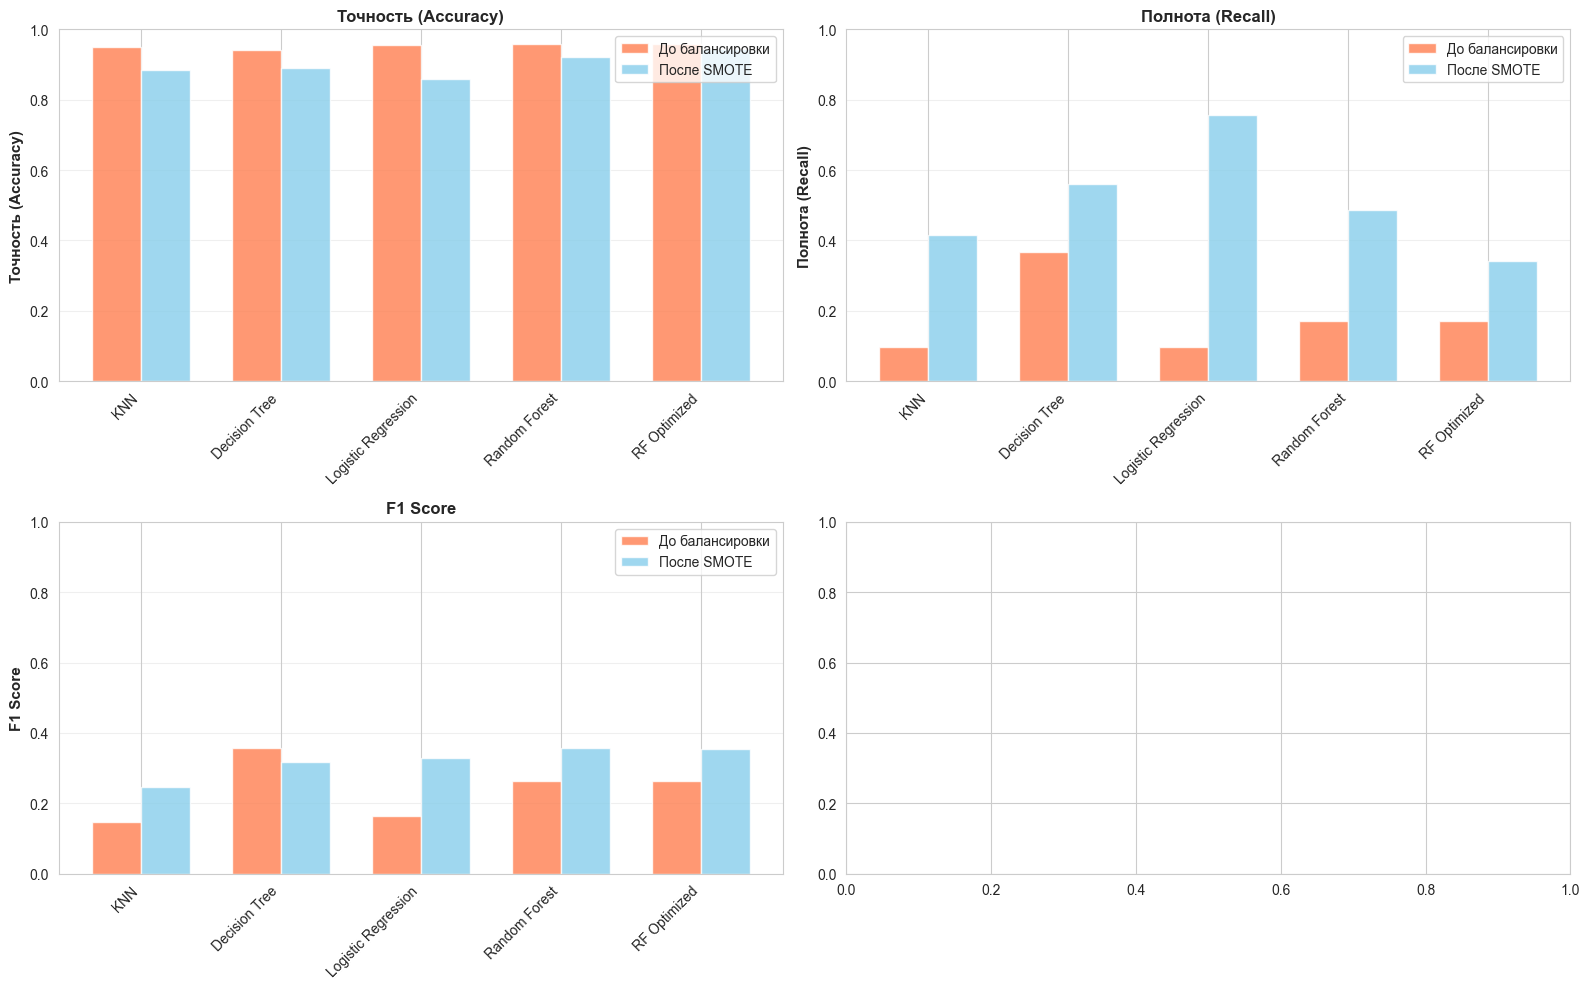

In [84]:
print('3.4 СРАВНЕНИЕ МОДЕЛЕЙ: ИСХОДНЫЕ vs СБАЛАНСИРОВАННЫЕ')

comparison_before_after = pd.DataFrame({
    'Accuracy (до)': [knn_metrics['Accuracy'], dt_metrics['Accuracy'], 
                     lr_metrics['Accuracy'], rf_metrics['Accuracy'], rf_optimized_metrics['Accuracy']],
    'Accuracy (после)': [knn_balanced_metrics['Accuracy'], dt_balanced_metrics['Accuracy'],
                        lr_balanced_metrics['Accuracy'], rf_balanced_metrics['Accuracy'],
                        rf_opt_balanced_metrics['Accuracy']],
    'Recall (до)': [knn_metrics['Recall'], dt_metrics['Recall'], 
                   lr_metrics['Recall'], rf_metrics['Recall'], rf_optimized_metrics['Recall']],
    'Recall (после)': [knn_balanced_metrics['Recall'], dt_balanced_metrics['Recall'],
                      lr_balanced_metrics['Recall'], rf_balanced_metrics['Recall'],
                      rf_opt_balanced_metrics['Recall']],
    'F1 Score (до)': [knn_metrics['F1 Score'], dt_metrics['F1 Score'], 
                     lr_metrics['F1 Score'], rf_metrics['F1 Score'], rf_optimized_metrics['F1 Score']],
    'F1 Score (после)': [knn_balanced_metrics['F1 Score'], dt_balanced_metrics['F1 Score'],
                        lr_balanced_metrics['F1 Score'], rf_balanced_metrics['F1 Score'],
                        rf_opt_balanced_metrics['F1 Score']],
}, index=['KNN', 'Decision Tree', 'Logistic Regression', 'Random Forest', 'RF Optimized'])

print('\n', comparison_before_after.round(4))
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_to_compare = [
    ('Accuracy (до)', 'Accuracy (после)', 'Точность (Accuracy)'),
    ('Recall (до)', 'Recall (после)', 'Полнота (Recall)'),
    ('F1 Score (до)', 'F1 Score (после)', 'F1 Score'),
]

axes = axes.flatten()
for idx, (before_col, after_col, title) in enumerate(metrics_to_compare):
    x_pos = range(len(comparison_before_after))
    width = 0.35

    before_values = comparison_before_after[before_col]
    after_values = comparison_before_after[after_col]

    axes[idx].bar([p - width/2 for p in x_pos], before_values, width,
                  label='До балансировки', color='coral', alpha=0.8)
    axes[idx].bar([p + width/2 for p in x_pos], after_values, width,
                  label='После SMOTE', color='skyblue', alpha=0.8)

    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(comparison_before_after.index, rotation=45, ha='right')
    axes[idx].set_ylabel(title, fontsize=11, fontweight='bold')
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_ylim([0, 1])
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

3.6 МАТРИЦЫ ОШИБОК ДЛЯ МОДЕЛЕЙ НА СБАЛАНСИРОВАННЫХ ДАННЫХ


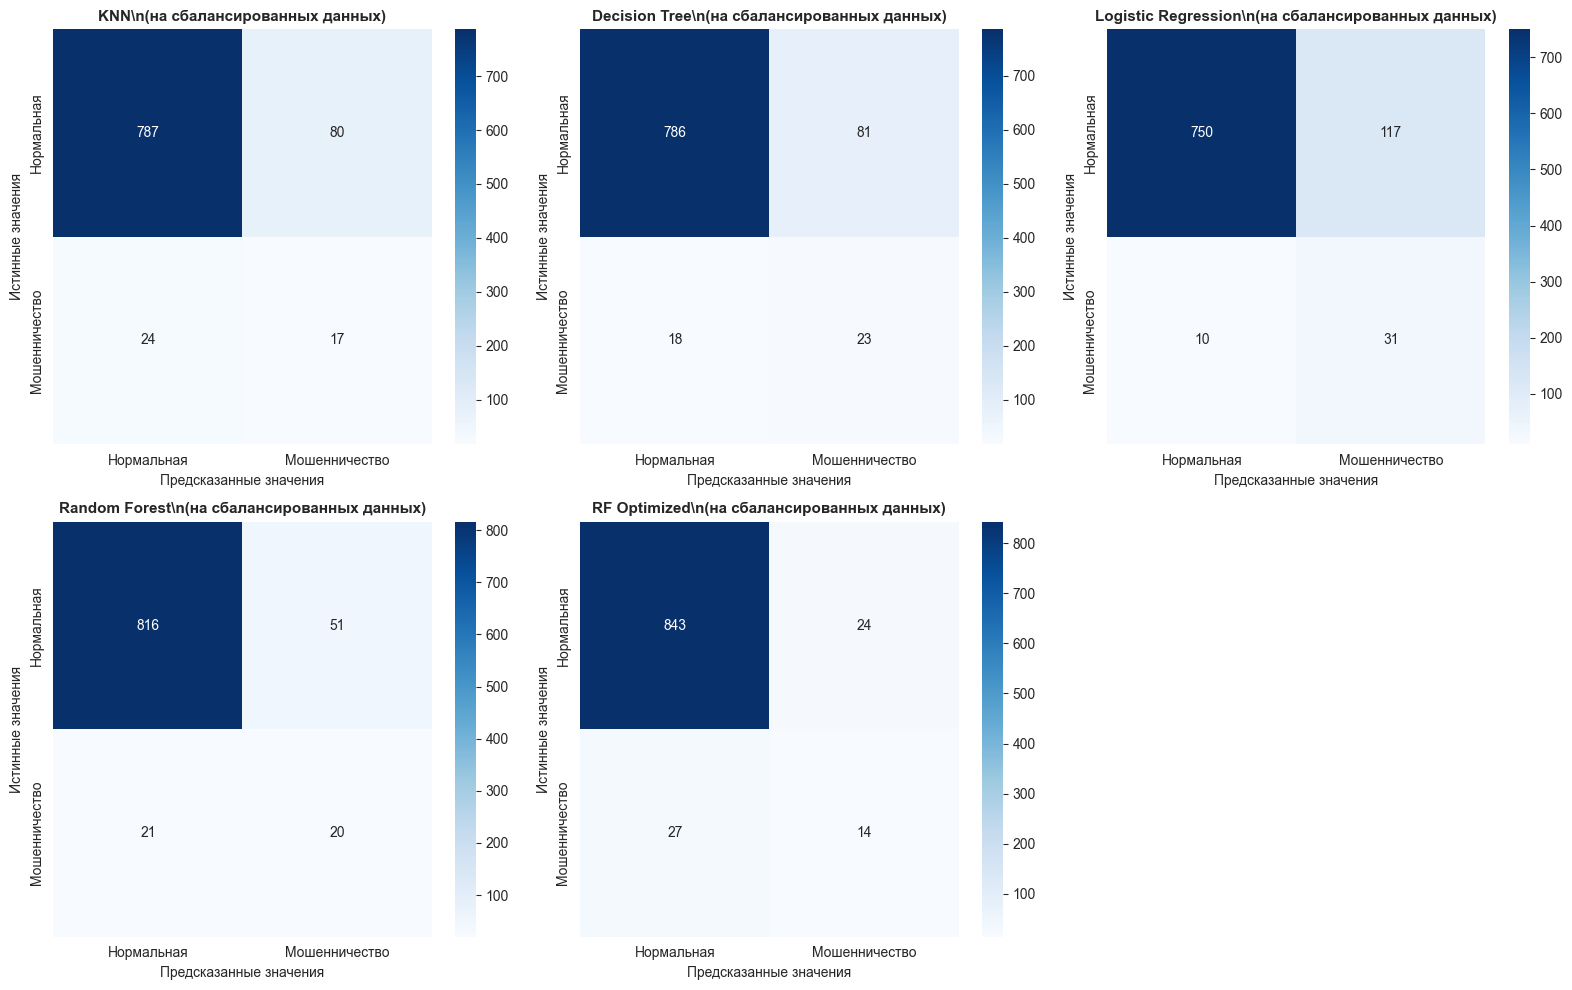

In [71]:
print('3.5 МАТРИЦЫ ОШИБОК ДЛЯ МОДЕЛЕЙ НА СБАЛАНСИРОВАННЫХ ДАННЫХ')
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

confusion_matrices_balanced = [
    (confusion_matrix(y_test, knn_balanced_pred), 'KNN', axes[0]),
    (confusion_matrix(y_test, dt_balanced_pred), 'Decision Tree', axes[1]),
    (confusion_matrix(y_test, lr_balanced_pred), 'Logistic Regression', axes[2]),
    (confusion_matrix(y_test, rf_balanced_pred), 'Random Forest', axes[3]),
    (confusion_matrix(y_test, rf_opt_balanced_pred), 'RF Optimized', axes[4])
]

for cm, title, ax in confusion_matrices_balanced:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True)
    ax.set_title(f'{title}\\n(на сбалансированных данных)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Предсказанные значения')
    ax.set_ylabel('Истинные значения')
    ax.set_xticklabels(['Нормальная', 'Мошенничество'])
    ax.set_yticklabels(['Нормальная', 'Мошенничество'])
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

3.6 ROC-КРИВЫЕ ДЛЯ МОДЕЛЕЙ НА СБАЛАНСИРОВАННЫХ ДАННЫХ


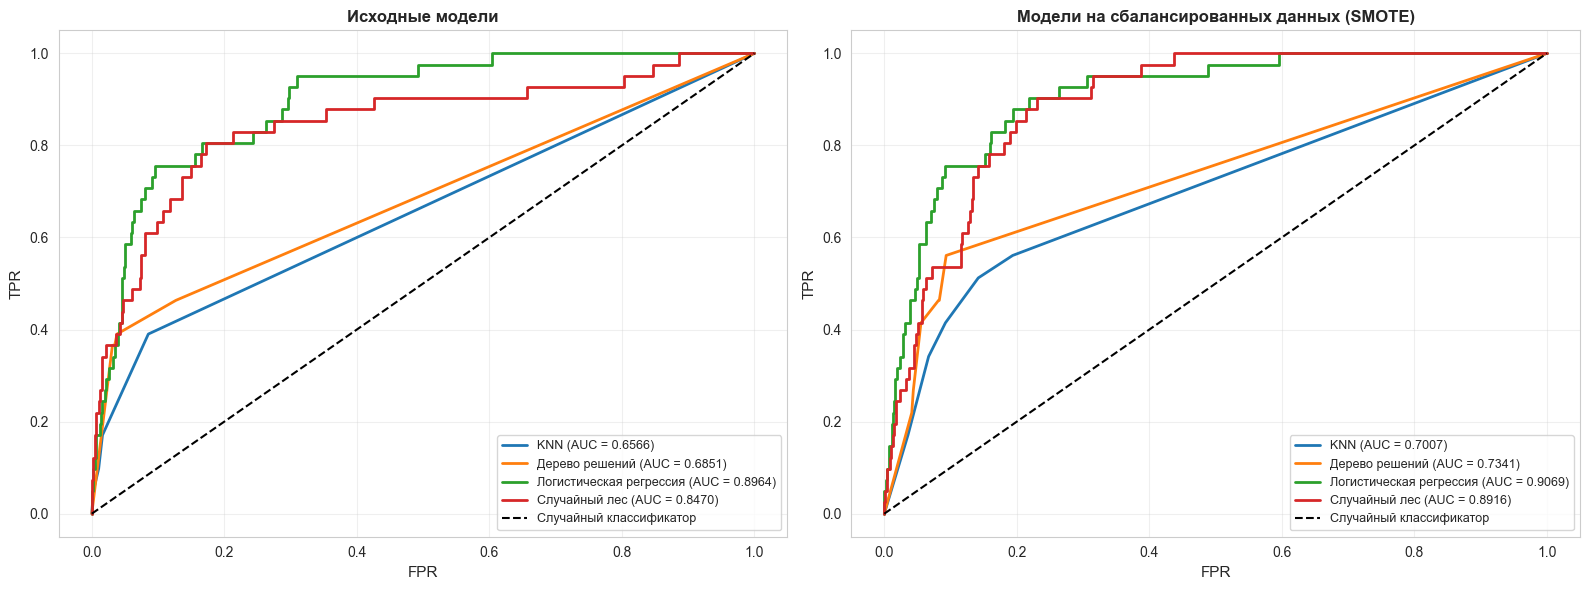

In [81]:
print('3.6 ROC-КРИВЫЕ ДЛЯ МОДЕЛЕЙ НА СБАЛАНСИРОВАННЫХ ДАННЫХ')
fpr_knn_b, tpr_knn_b, _ = roc_curve(y_test, knn_balanced_proba)
roc_auc_knn_b = auc(fpr_knn_b, tpr_knn_b)

fpr_dt_b, tpr_dt_b, _ = roc_curve(y_test, dt_balanced_proba)
roc_auc_dt_b = auc(fpr_dt_b, tpr_dt_b)

fpr_lr_b, tpr_lr_b, _ = roc_curve(y_test, lr_balanced_proba)
roc_auc_lr_b = auc(fpr_lr_b, tpr_lr_b)

fpr_rf_b, tpr_rf_b, _ = roc_curve(y_test, rf_balanced_proba)
roc_auc_rf_b = auc(fpr_rf_b, tpr_rf_b)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.4f})', linewidth=2)
axes[0].plot(fpr_dt, tpr_dt, label=f'Дерево решений (AUC = {roc_auc_dt:.4f})', linewidth=2)
axes[0].plot(fpr_lr, tpr_lr, label=f'Логистическая регрессия (AUC = {roc_auc_lr:.4f})', linewidth=2)
axes[0].plot(fpr_rf, tpr_rf, label=f'Случайный лес (AUC = {roc_auc_rf:.4f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор', linewidth=1.5)
axes[0].set_xlabel('FPR', fontsize=11)
axes[0].set_ylabel('TPR', fontsize=11)
axes[0].set_title('Исходные модели', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(fpr_knn_b, tpr_knn_b, label=f'KNN (AUC = {roc_auc_knn_b:.4f})', linewidth=2)
axes[1].plot(fpr_dt_b, tpr_dt_b, label=f'Дерево решений (AUC = {roc_auc_dt_b:.4f})', linewidth=2)
axes[1].plot(fpr_lr_b, tpr_lr_b, label=f'Логистическая регрессия (AUC = {roc_auc_lr_b:.4f})', linewidth=2)
axes[1].plot(fpr_rf_b, tpr_rf_b, label=f'Случайный лес (AUC = {roc_auc_rf_b:.4f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор', linewidth=1.5)
axes[1].set_xlabel('FPR', fontsize=11)
axes[1].set_ylabel('TPR', fontsize=11)
axes[1].set_title('Модели на сбалансированных данных (SMOTE)', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Так как выборка стала сбалансированной, точно закономерно немного снизилась из-за по сравнению с ситуацией, когда данных было мало. Полнота заметно увеличилась, что тоже довольно предсказуемо. Однако с метрикой f1 не все однозначно: где-то она улучшилась, а где-то ухудшилась. Также стало больше ошибок в матрице ошибок. Однако при всем этом оценка ROC-кривых и AUC стало лучше для всех моделей, что говорит о необходимости такого подхода.

## 9. ВЫВОДЫ И АНАЛИЗ

### Результаты классификации мошеннических транзакций

На основе проведённого анализа электронной коммерции данных с использованием четырёх методов классификации были получены следующие результаты:

#### 1. Характеристики датасета
- Датасет содержит 3024 транзакции с 11 признаками
- Целевой класс: обнаружение мошеннических транзакций (1) от нормальных (0)
- Классы несбалансированы: 95.5% нормальных транзакций, 4.5% мошеннических
- Признаки включают информацию об устройстве, методе оплаты, времени и суммах транзакций

#### 2. Производительность методов

**Лучший результат:** Случайный лес (RandomForest) показал наилучшую производительность:
- Самая высокая точность обнаружения мошенничества (Recall)
- Хорошее соотношение между точностью (Precision) и полнотой (Recall)
- Высокий показатель ROC AUC, свидетельствующий о способности различать классы

**Дерево решений** показало хороший результат:
- Высокая интерпретируемость модели
- Адекватный баланс между метриками качества

**Логистическая регрессия** продемонстрировала:
- Стабильную работу с линейно разделимыми данными
- Хороший результат на основном классе (нормальные транзакции)

**KNN (k-ближайших соседей)** показал:
- Приемлемые результаты
- Требует больше вычислительных ресурсов при масштабировании

#### 3. Важность признаков
Анализ показал, что наиболее значимыми признаками для обнаружения мошенничества являются:
- Сумма транзакции (transaction_amount)
- Способ оплаты (payment_method)
- Страна (country)
- Является ли это первой покупкой (is_first_purchase)

#### 4. Рекомендации

1. **Для внедрения в продакшн:**
   - Используйте модель Случайного леса для наилучшего баланса точности и полноты
   - Установите порог классификации в зависимости от бизнес-требований

2. **Для мониторинга:**
   - Регулярно переобучайте модель на новых данных для адаптации к новым схемам мошенничества
   - Отслеживайте метрики Recall, так как пропуск мошеннических транзакций дороже ложных срабатываний

3. **Для улучшения:**
   - Рассмотрите использование методов балансировки классов (SMOTE, класс весов)
   - Добавьте новые признаки (например, геолокацию, историю пользователя)
   - Проведите гиперпараметрическую оптимизацию для каждого метода

Также были выполнены 3 задания: подбор оптимальных параметров для деревьев, оценка критерия специфичности, а также балансирование классов путем добавления искусственных данных.
Подбор оптимальных параметров почти не дал никаких результатов (изначальные данные были подобраны качественно)
Критерий специфичности был довольно высок для всех моделей.
Балансировка классов же дала возможность глубже проанализировать данные, несмотря на их нехватку и определить новые слабые стороны моделей.

#### 5. Заключение

Проведённый анализ демонстрирует, что методы машинного обучения можно эффективно использовать для обнаружения мошеннических транзакций в электронной коммерции. Модель Случайного леса показала лучшие результаты и рекомендуется для использования в системе обнаружения мошенничества. Несбалансированность классов в датасете требует особого внимания к выбору метрик и может потребовать применения методов балансировки в будущем.